In [15]:
# Job_satisfaction 데이터셋 활용 회귀모형 만들기

In [17]:
# 데이터 로딩

import pandas as pd
import numpy as np

df = pd.read_csv("./data/job_satisfaction_10주차a.csv")
df.head()

,Review_ID,Inudusty,Industry_level_2,Occupation,Experience,Pros,Cons,overall,advancement_rating,compensation_rating,worklife_balance_rating,culture_rating,management_rating,recommend_to_friend
0,2864282,IT/웹/통신,쇼핑몰/오픈마켓,IT/인터넷,비지니스의 변화와 성장가운데 리스크 관리가 체계적으로 필요합니다,관료적이고 비효율적인 업무는 상대적으로 없고 비지니스가 성장하고 있기 때문에 그에따...,체계가 없고 체계가 없는 상태로 외형이 커져서 체계를 잡아가기가 어려움,3,3,3,3,1,1,Yes
1,2864160,IT/웹/통신,쇼핑몰/오픈마켓,인사/총무,개인의 커리어를 잘 신경쓰지 않음 그래도 한번쯤은 경험해볼만한 회사,여러 시도를 해볼 수 있고 한국에 없는 환경이라고 생각함,실무 모르는 외국인 디렉터가 지시를 찍어내림 이해할 수 없는 의사결정과 조직개편이 ...,2,4,4,3,3,2,No
2,2863336,IT/웹/통신,쇼핑몰/오픈마켓,경영/기획/컨설팅,워라벨은 안좋지만 그만큼 신입도 성장할 수 있는 기회를 주는 회사,"자유로운 분위기, 재택근무, 수평적문화, 능동적업무, 개발자의 경우 높은 연봉, 유...","워라벨 없음, 체계가 없음. 뭐든 알아서 해야함, 인수인계가 잘 되지 않음, 개인주...",4,4,3,1,4,1,Yes
3,2862116,IT/웹/통신,쇼핑몰/오픈마켓,마케팅/시장조사,성장 속도가 높은 회사라 본인 하기에 따라 기회가 많음,성과를 내기 위하여 스스로 업무 플랜을 세워서 끌고 갈 수 있는 장점이 있음,설치해야 하는 프로그램이 많고 전산 구조가 복잡하여 다소 번거로운 점이 많음,4,4,4,4,4,4,Yes
4,2861866,IT/웹/통신,쇼핑몰/오픈마켓,디자인,너무 좋았어요 내부 기업영향이 아주 좋답니다 최고의 기업 다운 모습을 보여줌이 너무...,너무 좋고 내부 기업 영향과 인사체계가 구체적이라 너무 좋아요 앞으로도 돌아가고싶은...,단점이 크게 없는거 같습니다 무어라 적어야 할지 모르겠습니다 이런 굴지의 대기업에...,5,5,5,5,5,5,Yes


In [19]:
df = df.drop(['Review_ID', 'Inudusty', 'Industry_level_2', 'Experience', 'Pros', 'Cons', 'recommend_to_friend'], axis=1)

df = pd.get_dummies(df)

df

,overall,advancement_rating,compensation_rating,worklife_balance_rating,culture_rating,management_rating,Occupation_IT/인터넷,Occupation_경영/기획/컨설팅,Occupation_교육,Occupation_금융/재무,...,Occupation_생산/제조,Occupation_생산관리/품질관리,Occupation_서비스/고객지원,Occupation_엔지니어링,Occupation_연구개발,Occupation_영업/제휴,Occupation_유통/무역,Occupation_의약,Occupation_인사/총무,Occupation_전문직
0,3,3,3,3,1,1,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,4,4,3,3,2,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,4,4,3,1,4,1,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,4,4,4,4,4,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,5,5,5,5,5,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003,3,3,3,1,5,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2004,5,4,4,5,2,5,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2005,4,3,3,3,4,3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2006,4,4,3,2,5,5,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [24]:
X = df.drop(['overall'], axis=1)
y = df[['overall']]

In [26]:
# train 데이터와 test 데이터 분리

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [28]:
# 모델 적합. 다중 회귀분석도 동일 모델 사용

from sklearn.linear_model import LinearRegression

mlr = LinearRegression()
mlr.fit(X_train, y_train)

LinearRegression()

In [30]:
X.columns

Index(['advancement_rating', 'compensation_rating', 'worklife_balance_rating',
       'culture_rating', 'management_rating', 'Occupation_IT/인터넷',
       'Occupation_경영/기획/컨설팅', 'Occupation_교육', 'Occupation_금융/재무',
       'Occupation_디자인', 'Occupation_마케팅/시장조사', 'Occupation_미디어/홍보',
       'Occupation_법률/법무', 'Occupation_생산/제조', 'Occupation_생산관리/품질관리',
       'Occupation_서비스/고객지원', 'Occupation_엔지니어링', 'Occupation_연구개발',
       'Occupation_영업/제휴', 'Occupation_유통/무역', 'Occupation_의약',
       'Occupation_인사/총무', 'Occupation_전문직'],
      dtype='object')

In [40]:
# 예측값과 실제값 비교

y_pred = mlr.predict(X_test)

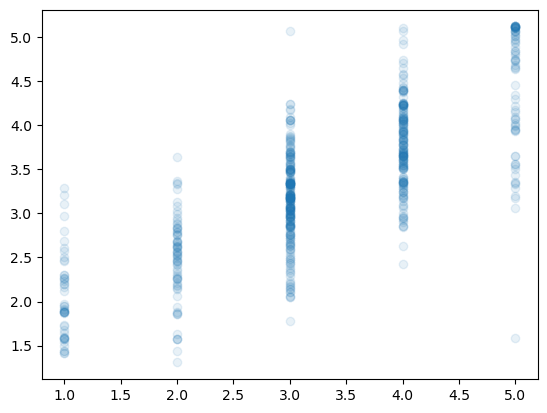

In [52]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha = 0.1)
plt.show()

#일치할수록 직선 형태이다

In [44]:
#회귀계수 계산
#각 변수의 기울기 (회귀계수) 확인

X.columns

Index(['advancement_rating', 'compensation_rating', 'worklife_balance_rating',
       'culture_rating', 'management_rating', 'Occupation_IT/인터넷',
       'Occupation_경영/기획/컨설팅', 'Occupation_교육', 'Occupation_금융/재무',
       'Occupation_디자인', 'Occupation_마케팅/시장조사', 'Occupation_미디어/홍보',
       'Occupation_법률/법무', 'Occupation_생산/제조', 'Occupation_생산관리/품질관리',
       'Occupation_서비스/고객지원', 'Occupation_엔지니어링', 'Occupation_연구개발',
       'Occupation_영업/제휴', 'Occupation_유통/무역', 'Occupation_의약',
       'Occupation_인사/총무', 'Occupation_전문직'],
      dtype='object')

In [46]:
# X변수들에 대한 기울기
print(mlr.coef_)

[[ 0.14697112  0.18339355  0.14922495  0.16303136  0.23947588  0.08039311
   0.07474588  0.01382194 -0.15598653 -0.03040538 -0.06406424  0.01120072
  -0.28508494  0.03383914  0.07157906 -0.09575441  0.6421278  -0.15369186
  -0.19766526  0.06487545  0.         -0.08667935  0.07674888]]


In [48]:
# y절편
print(mlr.intercept_)

[0.62485072]


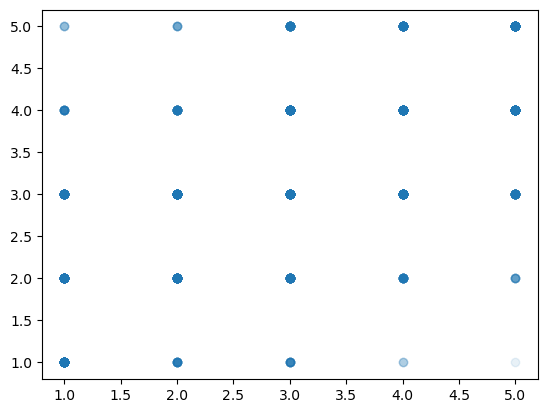

In [54]:
# 변수별 상관 확인 EDA

# 업무와 워라밸 평점과 전체 평점 간 상관관계
plt.scatter(df[['worklife_balance_rating']], df[['overall']], alpha=0.1)
plt.show()

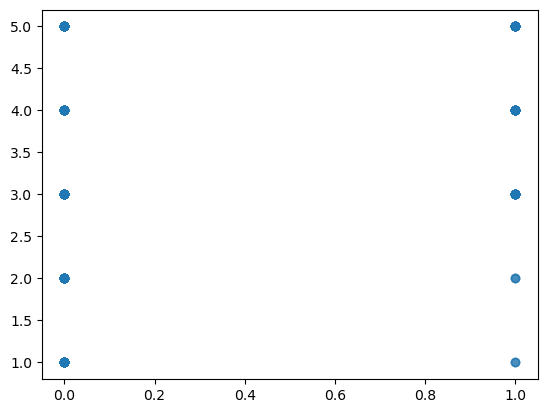

In [56]:
# 변수별 상관 확인
# IT 직무와 전체 평점 간 상관관계
plt.scatter(df[['Occupation_IT/인터넷']], df[['overall']], alpha=0.1)
plt.show()

In [58]:
# 성능평가

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [60]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

In [62]:
print("MAE : %.2f" %mae)
print("MSE : %.2f" %mse)
print("RMSE : %.2f" %rmse)
print("R2 : %.2f" %r2)

MAE : 0.51
MSE : 0.45
RMSE : 0.67
R2 : 0.61


In [64]:
# 60211356 장유진